In [56]:
import pandas as pd
import numpy as np

df = pd.read_parquet("sample_data/dataset_limpo.parquet")
# Vamos padronizar os nomes das colunas para minúsculas caso ainda não estejam:
df.columns = [col.lower() for col in df.columns]

# 1. Limpeza básica de espaços em strings e conversão para minúsculas
df['municipio'] = df['municipio'].str.strip().str.lower()
df['uf'] = df['uf'].str.strip().str.lower()
df['especie_arma'] = df['especie_arma'].str.strip().str.lower()
df['municipio'] = df['municipio'].replace('', 'não informado').fillna('não informado')
df['uf'] = df['uf'].replace('', 'ni').fillna('ni')

# 2. Criar variáveis indicadoras (One-Hot Encoding) para as principais espécies de armas
# Exemplo: transformar 'espingarda', 'pistola', 'revólver' em colunas binárias/contadoras
especies_frequentes = df['especie_arma'].value_counts().head(5).index.tolist()
df_filtrado = df[df['especie_arma'].isin(especies_frequentes)]

# Tabela pivotada para contar a quantidade de cada tipo de arma por Município e UF
pivot_especies = pd.crosstab(
    [df_filtrado['municipio'], df_filtrado['uf']], 
    df_filtrado['especie_arma'], 
    values=df_filtrado['total'], 
    aggfunc='sum'
).fillna(0)

# 3. Consolidar o total geral de armas apreendidas e métricas por município
perfil_municipal = df_filtrado.groupby(['municipio', 'uf']).agg(
    total_apreensoes=('total', 'sum'),
    ocorrencias_distintas=('tipo_ocorrencia', 'count')
).reset_index()

# Juntar as contagens de espécies de armas ao perfil municipal
perfil_municipal = perfil_municipal.merge(pivot_especies, on=['municipio', 'uf'])

print(f"Dimensões da Matriz de Perfis Municipais: {perfil_municipal.shape}")
display(perfil_municipal.head())

Dimensões da Matriz de Perfis Municipais: (4784, 9)


,municipio,uf,total_apreensoes,ocorrencias_distintas,carabina,espingarda,pistola,revolver,rifle
0,abadia de goiás,go,52,31,5.0,11.0,8.0,25.0,3.0
1,abadia dos dourados,mg,3,3,1.0,0.0,0.0,2.0,0.0
2,abadiânia,go,9,7,0.0,2.0,1.0,3.0,3.0
3,abaetetuba,pa,68,27,0.0,44.0,3.0,18.0,3.0
4,abaeté,mg,49,26,0.0,12.0,8.0,28.0,1.0


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# 1. Isolar as variáveis numéricas
# Removemos 'municipio' e 'uf' para agrupar as cidades puramente pelo comportamento das apreensões
colunas_numericas = perfil_municipal.columns.drop(['municipio', 'uf'])
X = perfil_municipal[colunas_numericas]

# 2. Padronizar os dados (Etapa crítica)
# Evita que a coluna 'total_apreensoes' (números altos) ofusque a contagem de armas específicas (números baixos)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Aplicar o DBSCAN
# eps: raio de vizinhança (você precisará testar valores como 0.3, 0.5, 1.0, 2.0)
# min_samples: quantidade mínima de cidades parecidas para formar um grupo
dbscan = DBSCAN(eps=2, min_samples=3)
perfil_municipal['cluster'] = dbscan.fit_predict(X_scaled)

# 4. Explorar os clusters inter-estaduais
# O cluster '-1' é considerado ruído (cidades com perfil muito atípico, outliers)
# cidades_agrupadas = perfil_municipal[perfil_municipal['cluster'] != -1]
cidades_agrupadas = perfil_municipal

# Contar quantas UFs diferentes existem dentro de cada cluster
diversidade_ufs = cidades_agrupadas.groupby('cluster').agg(
    qtd_cidades=('municipio', 'count'),
    qtd_ufs_diferentes=('uf', 'nunique'),
    lista_ufs=('uf', lambda x: ', '.join(x.unique()))
).reset_index()

display(diversidade_ufs)

# Exibir os detalhes de um cluster específico que tenha cidades de várias UFs
# (Altere o valor 0 para o número do cluster que deseja investigar)
cluster_alvo = perfil_municipal[perfil_municipal['cluster'] == 0]
display(cluster_alvo.sort_values('total_apreensoes', ascending=False).head(10))

NameError: name 'perfil_municipal' is not defined

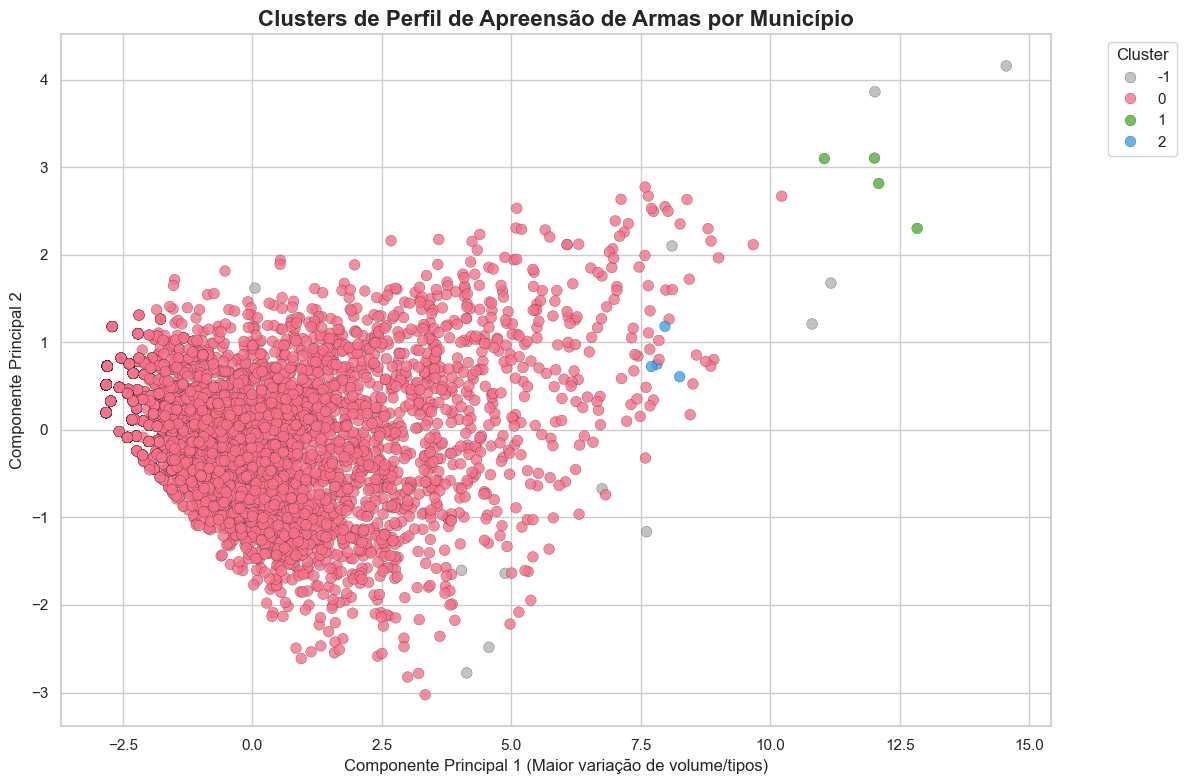

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 1. Comprimir as múltiplas variáveis (X_scaled) em 2 eixos (X e Y) usando PCA
pca = PCA(n_components=2)
componentes = pca.fit_transform(X_scaled)

perfil_municipal['pca_x'] = componentes[:, 0]
perfil_municipal['pca_y'] = componentes[:, 1]

# 2. Configurar o visual do gráfico
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# 3. Criar uma paleta de cores destacando os ruídos (Outliers / Cluster -1)
# O cluster -1 (cidades de perfil atípico) ficará em cinza claro para não poluir a visualização
clusters_unicos = sorted(perfil_municipal['cluster'].unique())
paleta_cores = sns.color_palette("husl", len(clusters_unicos) - (1 if -1 in clusters_unicos else 0))

mapa_cores = {}
idx_cor = 0
for c in clusters_unicos:
    if c == -1:
        mapa_cores[c] = (0.7, 0.7, 0.7, 0.5) # Cinza com transparência para o ruído
    else:
        mapa_cores[c] = paleta_cores[idx_cor]
        idx_cor += 1

# 4. Plotar os dados
sns.scatterplot(
    data=perfil_municipal,
    x='pca_x',
    y='pca_y',
    hue='cluster',
    palette=mapa_cores,
    alpha=0.8,
    s=60, # Tamanho dos pontos
    edgecolor="k",
    linewidth=0.2
)

# 5. Ajustes de layout
plt.title("Clusters de Perfil de Apreensão de Armas por Município", fontsize=16, fontweight='bold')
plt.xlabel("Componente Principal 1 (Maior variação de volume/tipos)", fontsize=12)
plt.ylabel("Componente Principal 2", fontsize=12)
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()